In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
import matplotlib.pyplot as plt

In [6]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    "CNN_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150,150),
    batch_size=32
)
val_ds=tf.keras.utils.image_dataset_from_directory(
    "CNN_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [7]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 150, 150, 3)
(32,)


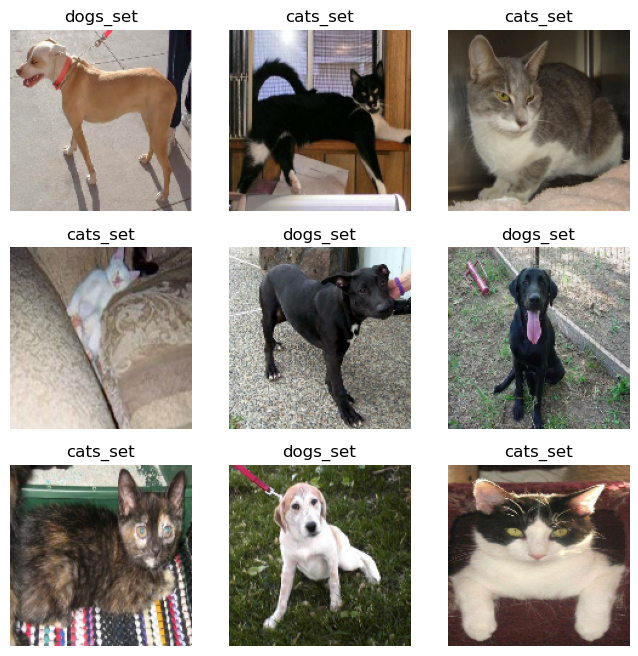

In [11]:
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis(False)
plt.show()

In [19]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [35]:
from tensorflow.keras.layers import Rescaling,Dropout
model=Sequential([
    tf.keras.Input(shape=(150,150,3)),
    data_augmentation,
    Rescaling(1./255),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_8 (Rescaling)              │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [39]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 808ms/step - accuracy: 0.5013 - loss: 0.8342 - val_accuracy: 0.4950 - val_loss: 0.6935
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 728ms/step - accuracy: 0.4837 - loss: 0.6935 - val_accuracy: 0.5100 - val_loss: 0.6931
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 740ms/step - accuracy: 0.5188 - loss: 0.6934 - val_accuracy: 0.5850 - val_loss: 0.6924
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 810ms/step - accuracy: 0.5387 - loss: 0.6944 - val_accuracy: 0.5100 - val_loss: 0.6922
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 786ms/step - accuracy: 0.5300 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 761ms/step - accuracy: 0.5750 - loss: 0.6855 - val_accuracy: 0.5200 - val_loss: 0.6936
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 794ms/step - accuracy: 0.5975 - loss: 0.6727 - val_accuracy: 0.5550 - val_loss: 0.6891
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 836ms/step - accuracy: 0.5788 - loss: 0.6889 - val_accu

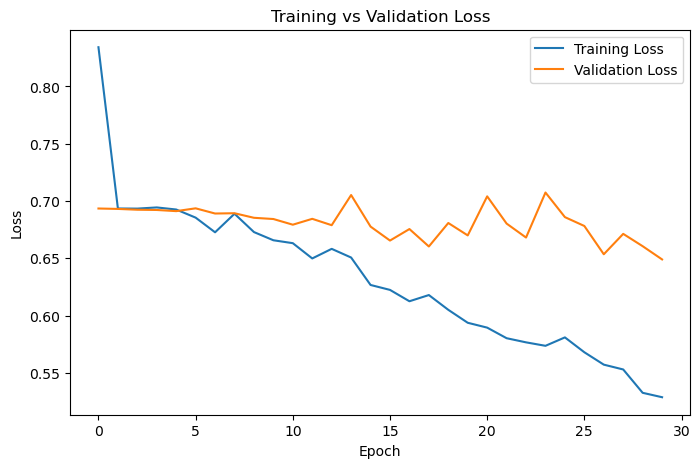

In [40]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

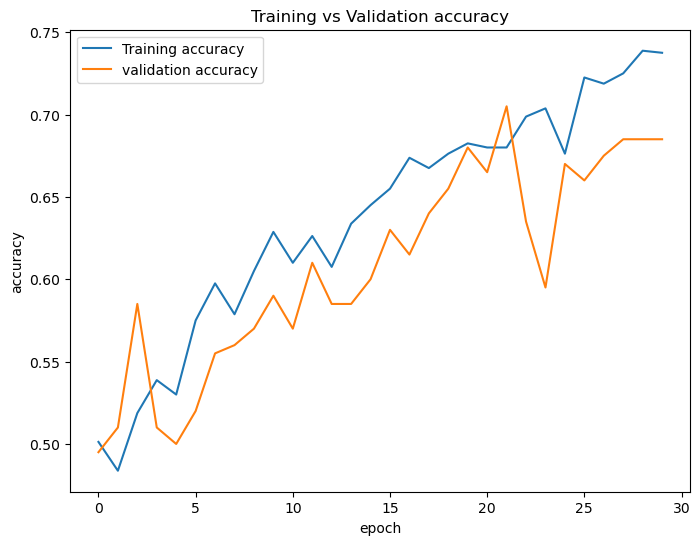

In [41]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'],label='Training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Training vs Validation accuracy')
plt.show()

In [42]:
loss, accuracy = model.evaluate(val_ds)
print("Loss:", loss)
print("Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6850 - loss: 0.6490 
Loss: 0.6490334272384644
Accuracy: 0.6850000023841858
